# Two-Stage Decoder Rectangle-Focused Model

This notebook keeps the same Task 8 Stage 1 model and decoder-style Stage 2 model, but pushes harder on rectangle reconstruction with rectangle-focused sampling, stronger boundary weighting, and a larger decoder. Outputs are written to `outputs/2_stage_decoder_rectangle_model/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from config import Stage1ModelConfig, Stage2ModelConfig, StageTrainingConfig, TwoStageRunConfig, TwoStageStackConfig
from pipeline.run import run_two_stage_once
from models import set_torch_seed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
set_torch_seed(SEED)

OUTPUT_ROOT = ROOT / 'outputs' / '2_stage_decoder_rectangle_model'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

N_values = [2, 4, 6, 8, 10]
training_sizes = [2000, 4000, 6000, 8000, 10000]
validation_sizes = [500, 800, 1200, 1600, 2000]

stage1_config = Stage1ModelConfig(
    hidden_layer_sizes=(128, 256, 128),
    dropout_rates=(0.2, 0.2, 0.2),
    training=StageTrainingConfig(
        epochs=200,
        batch_size=32,
        learning_rate=0.0005,
        validation_frequency=10,
        verbose=True,
        early_stopping_patience=10,
    ),
)

stage2_config = Stage2ModelConfig(
    hidden_layer_sizes=(256, 512),
    dropout_rates=(0.15, 0.15),
    model_type='conv_decoder',
    latent_grid_size=16,
    latent_channels=128,
    decoder_channels=(128, 96, 64, 32),
    use_rectangle_edge_weighting=True,
    use_foreground_pos_weight=False,
    rectangle_edge_weight=4.0,
    rectangle_edge_width=3,
    edge_weight_mode='rectangle',
    training=StageTrainingConfig(
        epochs=150,
        batch_size=128,
        learning_rate=0.0006,
        validation_frequency=60,
        verbose=True,
        early_stopping_patience=20,
        min_epochs=40,
        min_improvement=0.003,
        lr_drop_factor=0.5,
        lr_drop_period=70,
        weight_decay=0.0003,
        gradient_clip_norm=0.8,
        loss_type='bce_dice',
        dice_loss_weight=1.0,
        dice_smooth=1.0,
    ),
)

print('Device:', DEVICE)
print('Output root:', OUTPUT_ROOT)
print('Sweep:', N_values, training_sizes, validation_sizes)
print('Stage 1:', stage1_config)
print('Stage 2:', stage2_config)

def plot_history(history: dict, title: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(1, len(history['train_loss']) + 1), history['train_loss'], marker='o')
    axes[0].set_title(f'{title} Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['validation_steps'], history['val_loss'], marker='o', color='tab:orange')
    axes[1].set_title(f'{title} Validation Loss')
    axes[1].set_xlabel('Validation Step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

Device: cuda
Output root: c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\2_stage_decoder_rectangle_model
Sweep: [2, 4, 6, 8, 10] [2000, 4000, 6000, 8000, 10000] [500, 800, 1200, 1600, 2000]
Stage 1: Stage1ModelConfig(hidden_layer_sizes=(128, 256, 128), dropout_rates=(0.2, 0.2, 0.2), training=StageTrainingConfig(epochs=200, batch_size=32, learning_rate=0.0005, validation_frequency=10, verbose=True, early_stopping_patience=10, min_epochs=None, min_improvement=None, lr_drop_factor=None, lr_drop_period=None, weight_decay=0.0, gradient_clip_norm=None, loss_type='bce', dice_loss_weight=0.0, dice_smooth=1.0))
Stage 2: Stage2ModelConfig(hidden_layer_sizes=(256, 512), dropout_rates=(0.15, 0.15), model_type='conv_decoder', latent_grid_size=16, latent_channels=128, decoder_channels=(128, 96, 64, 32), use_rectangle_edge_weighting=True, use_foreground_pos_weight=False, rectangle_edge_weight=4.0, rectangle_edge_width=3, edge_weight_mode='rectangle', training=StageTrainingConfig(epochs=150, b

Running N=2 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\2_stage_decoder_rectangle_model\N_2
Epoch 1/200 | step 10 | train_loss=0.835679 | val_loss=0.638522
Epoch 1/200 | step 20 | train_loss=0.725141 | val_loss=0.518820
Epoch 1/200 | step 30 | train_loss=0.664168 | val_loss=0.393244
Epoch 1/200 | step 40 | train_loss=0.596145 | val_loss=0.273695
Epoch 1/200 | step 50 | train_loss=0.533617 | val_loss=0.186558
Epoch 1/200 | step 60 | train_loss=0.483988 | val_loss=0.134152
Epoch 2/200 | step 70 | train_loss=0.158260 | val_loss=0.102825
Epoch 2/200 | step 80 | train_loss=0.154562 | val_loss=0.085821
Epoch 2/200 | step 90 | train_loss=0.143669 | val_loss=0.073805
Epoch 2/200 | step 100 | train_loss=0.139256 | val_loss=0.052236
Epoch 2/200 | step 110 | train_loss=0.132961 | val_loss=0.031320
Epoch 2/200 | step 120 | train_loss=0.126296 | val_loss=0.029904
Epoch 3/200 | step 130 | train_loss=0.092477 | val_loss=0.028274
Epoch 3/200 | step 140 | train_loss=0.086241 | val_loss=0.

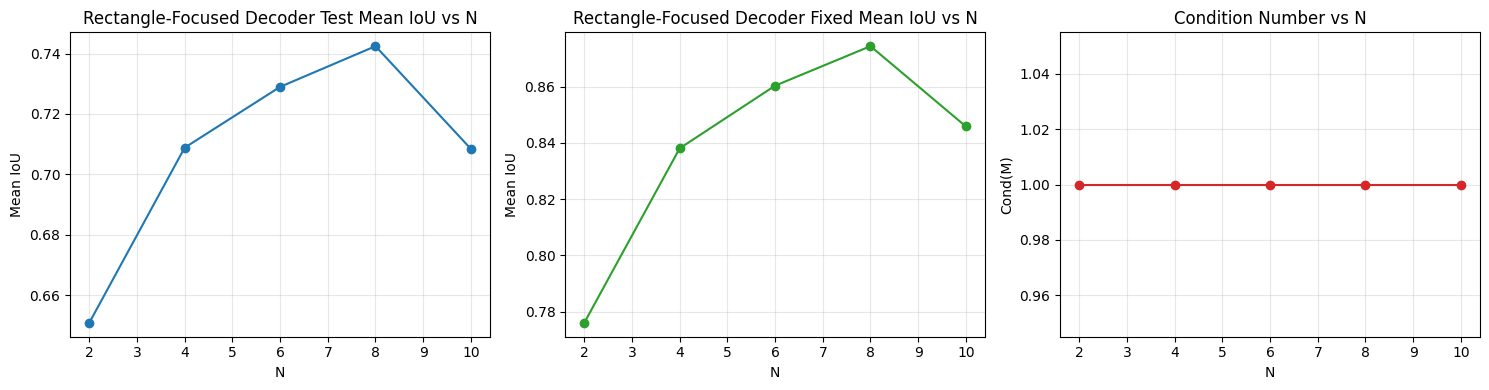

[{'N': 2,
  'stage2_test_iou': 0.6507692980309254,
  'stage2_fixed_iou': 0.7760000288264771,
  'rectangle_test_iou': 0.6596582000482322,
  'annulus_test_iou': 0.6349748769736608},
 {'N': 4,
  'stage2_test_iou': 0.7088031625165686,
  'stage2_fixed_iou': 0.8380467025246823,
  'rectangle_test_iou': 0.710722614535895,
  'annulus_test_iou': 0.5405424414621115},
 {'N': 6,
  'stage2_test_iou': 0.7289549195804912,
  'stage2_fixed_iou': 0.8603196008416486,
  'rectangle_test_iou': 0.757289821641834,
  'annulus_test_iou': 0.612639565654413},
 {'N': 8,
  'stage2_test_iou': 0.7424371954311064,
  'stage2_fixed_iou': 0.8743730343879976,
  'rectangle_test_iou': 0.7460817058874932,
  'annulus_test_iou': 0.6845423088491355},
 {'N': 10,
  'stage2_test_iou': 0.7083974693592425,
  'stage2_fixed_iou': 0.8458207297319046,
  'rectangle_test_iou': 0.7527981469200634,
  'annulus_test_iou': 0.6042654640126928}]

In [2]:
def make_run_config(index: int, n_value: int) -> TwoStageRunConfig:
    return TwoStageRunConfig(
        N=n_value,
        training_samples=training_sizes[index],
        validation_samples=validation_sizes[index],
        test_samples=500,
        rho=0.8,
        grid_size=32,
        threshold=0.5,
        use_validation_threshold_sweep=True,
        noise_level=0.01,
        seed=SEED + index,
        training_shape_weights=(
            ('rectangle', 0.30),
            ('two_circles', 0.30),
            ('annulus', 0.15),
            ('ellipse', 0.15),
            ('circle', 0.10),
        ),
        model=TwoStageStackConfig(stage1=stage1_config, stage2=stage2_config),
        output_dir=OUTPUT_ROOT,
    )


sweep_rows = []
for index, n_value in enumerate(N_values):
    run_config = make_run_config(index, n_value)
    print(f'Running N={n_value} -> {run_config.run_output_dir}')
    summary = run_two_stage_once(run_config, device=DEVICE)
    plot_history(summary['stage1_history'], 'Task 8 Stage 1', run_config.run_output_dir / 'stage1_losses.png')
    plot_history(summary['stage2_history'], 'Stage 2 Decoder Rectangle Focused', run_config.run_output_dir / 'general_losses.png')
    sweep_rows.append(summary)

with (OUTPUT_ROOT / 'sweep_summary.json').open('w', encoding='utf-8') as handle:
    json.dump({'runs': sweep_rows}, handle, indent=2)

test_ious = [row['metrics']['stage2_test']['mean_iou'] for row in sweep_rows]
fixed_ious = [row['metrics']['stage2_fixed']['mean_iou'] for row in sweep_rows]
condition_numbers = [row['condition_number'] for row in sweep_rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(N_values, test_ious, marker='o')
axes[0].set_title('Rectangle-Focused Decoder Test Mean IoU vs N')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Mean IoU')
axes[0].grid(True, alpha=0.3)
axes[1].plot(N_values, fixed_ious, marker='o', color='tab:green')
axes[1].set_title('Rectangle-Focused Decoder Fixed Mean IoU vs N')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Mean IoU')
axes[1].grid(True, alpha=0.3)
axes[2].plot(N_values, condition_numbers, marker='o', color='tab:red')
axes[2].set_title('Condition Number vs N')
axes[2].set_xlabel('N')
axes[2].set_ylabel('Cond(M)')
axes[2].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'sweep_plots.png', dpi=150, bbox_inches='tight')
plt.show()

[{
    'N': row['config']['N'],
    'stage2_test_iou': row['metrics']['stage2_test']['mean_iou'],
    'stage2_fixed_iou': row['metrics']['stage2_fixed']['mean_iou'],
    'rectangle_test_iou': row['metrics_by_shape']['stage2_test']['rectangle']['mean_iou'],
    'annulus_test_iou': row['metrics_by_shape']['stage2_test']['annulus']['mean_iou'],
} for row in sweep_rows]